In [1]:
from src.experiments import Experiments
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
exp = Experiments()

# **Experiment 1**
## **Testing different values of parameter a**

In [3]:
pdf1 = PdfPages("BayesianSimulatedData1.pdf")

### **LDA - scheme 1**

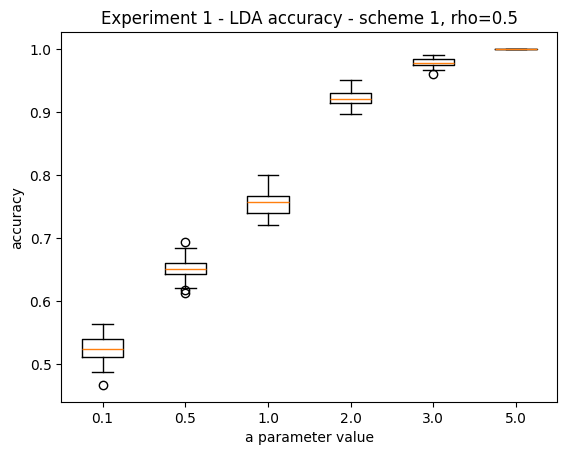

In [4]:
exp.experiment_a(method_name="LDA", scheme=1, pdf=pdf1)

### **LDA - scheme 2**

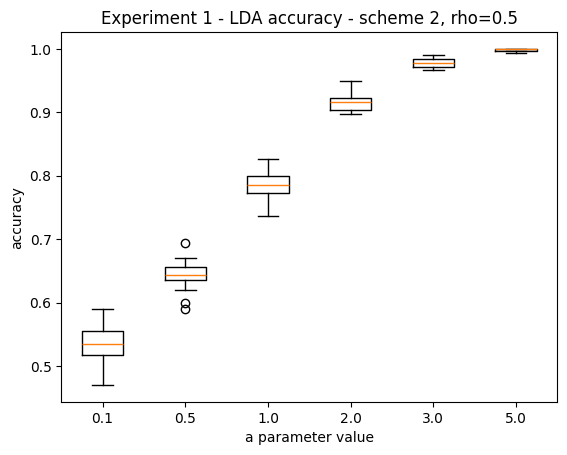

In [5]:
exp.experiment_a(method_name="LDA", scheme=2, pdf=pdf1)

### **QDA - scheme 1**

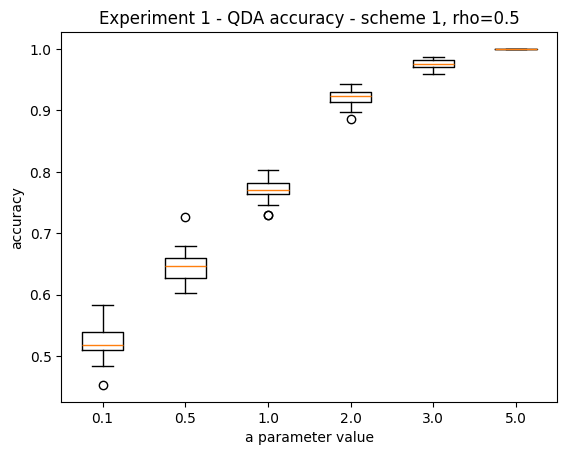

In [6]:
exp.experiment_a(method_name="QDA", scheme=1, pdf=pdf1)

### **QDA - scheme 2**

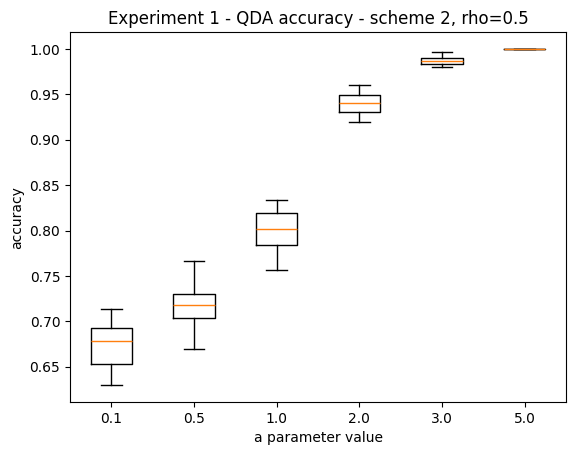

In [7]:
exp.experiment_a(method_name="QDA", scheme=2, pdf=pdf1)

### **Naive Bayes - scheme 1**

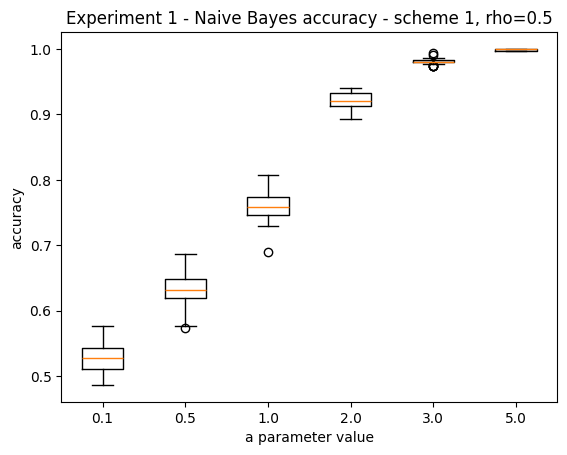

In [8]:
exp.experiment_a(method_name="Naive Bayes", scheme=1, pdf=pdf1)

### **Naive Bayes - scheme 2**

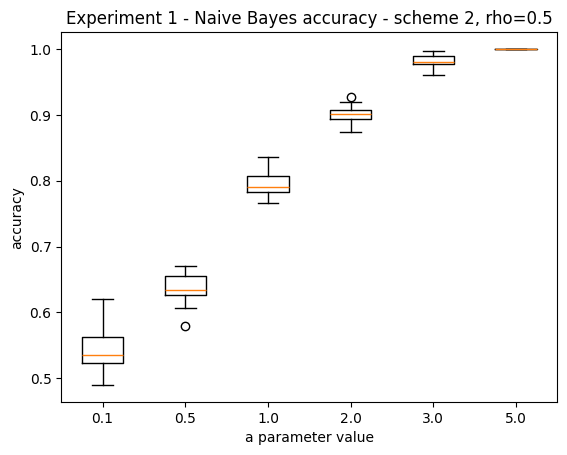

In [9]:
exp.experiment_a(method_name="Naive Bayes", scheme=2, pdf=pdf1)

In [10]:
pdf1.close()

#### **Comments on comparison**

Analysis shows that the bigger the value of parameter a the higher classification accuracy. It is due to the fact that for a bigger value of parameter a, class separation is better which makes classification task easier.<br>
In scheme 1 (LDA assumptions are satisfied), all three methods achieve similar results, especially for bigger value of parameter a.<br>
In scheme 2 (LDA assumptions are not satisfied), you can see subtle but visible differences between LDA and QDA results - they are slightly better for QDA since LDA assumptions are not satisfied.

# **Experiment 2**
## **Testing different values of parameter rho**

In [11]:
pdf2 = PdfPages("BayesianSimulatedData2.pdf")

### **LDA - scheme 1**

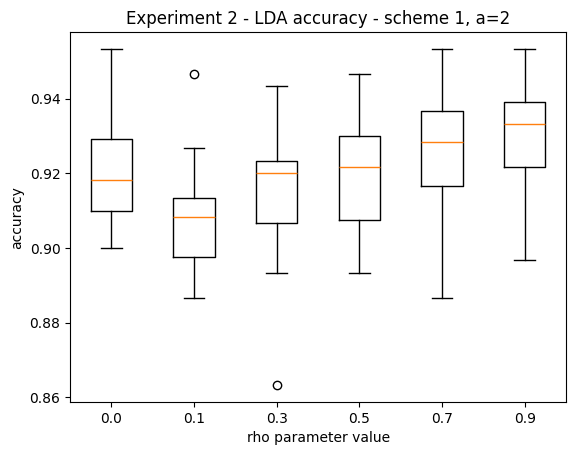

In [12]:
exp.experiment_rho(method_name="LDA", scheme=1, pdf=pdf2)

### **LDA - scheme 2**

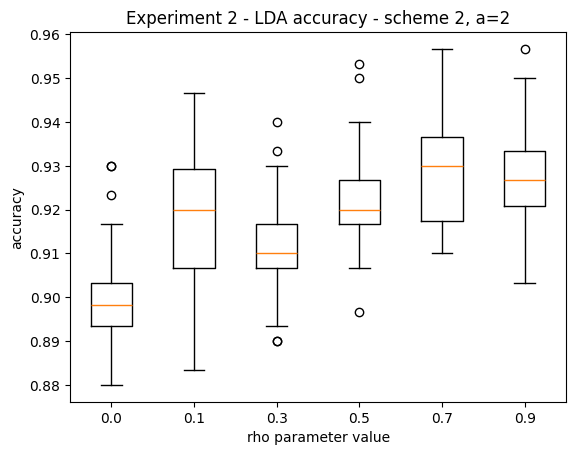

In [13]:
exp.experiment_rho(method_name="LDA", scheme=2, pdf=pdf2)

### **QDA - scheme 1**

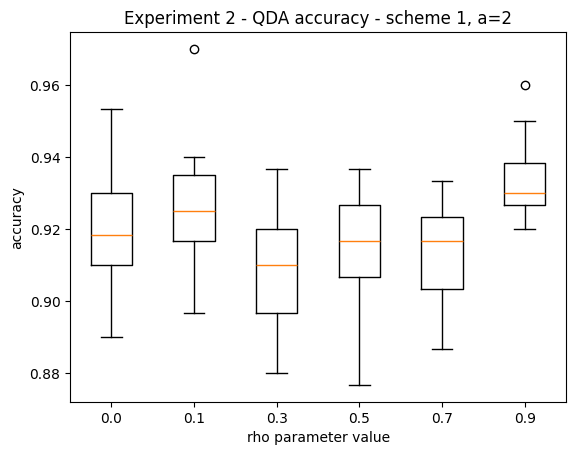

In [14]:
exp.experiment_rho(method_name="QDA", scheme=1, pdf=pdf2)

### **QDA - scheme 2**

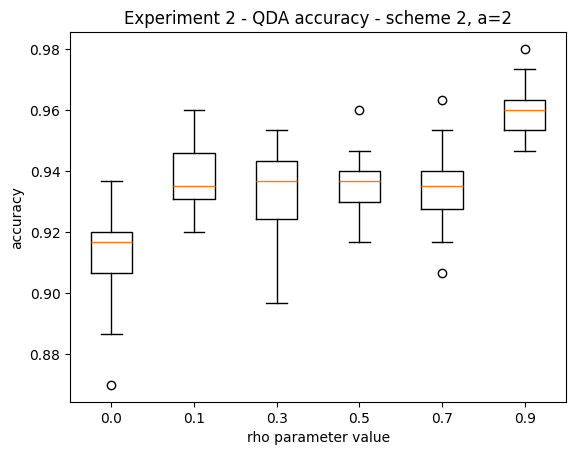

In [15]:
exp.experiment_rho(method_name="QDA", scheme=2, pdf=pdf2)

### **Naive Bayes - scheme 1**

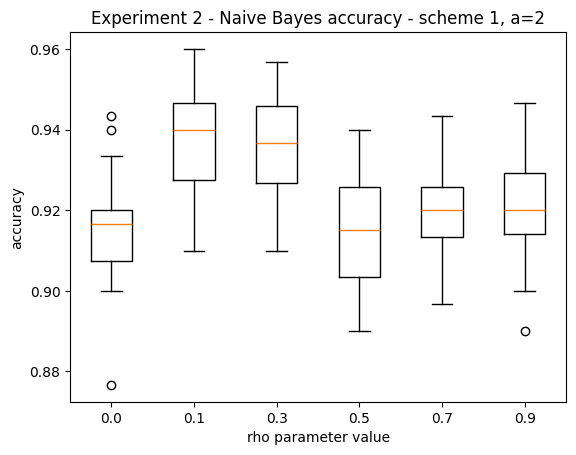

In [16]:
exp.experiment_rho(method_name="Naive Bayes", scheme=1, pdf=pdf2)

### **Naive Bayes - scheme 2**

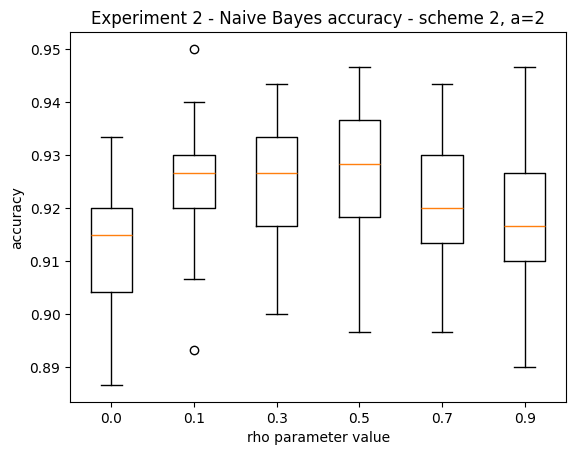

In [17]:
exp.experiment_rho(method_name="Naive Bayes", scheme=2, pdf=pdf2)

In [18]:
pdf2.close()

#### **Comments on comparison**

The value of rho changes the correlation between features.<br>
In scheme 1, features are generated independently so changing the value of the rho parameter does not affect the data structure significantly. The LDA and QDA methods achieve very similar and high results while Naive Bayes achieves subtly slightly lower accuracy which may be due to the simplified assumption of features conditional independence.<br>
In scheme 2, there is a difference in the class covariance matrices. In this scheme LDA assumptions are not met. However, all methods achieve high classification accuracy.

LDA performance in scheme 2 is good despite the fact that the scheme 2 does not meet LDA assumptions. This might be due to the fact that a parameter is quite big and equals 2 and the classes are well separated.

# **Experiment 3**

In [19]:
pdf3 = PdfPages("BayesianSimulatedData3.pdf")

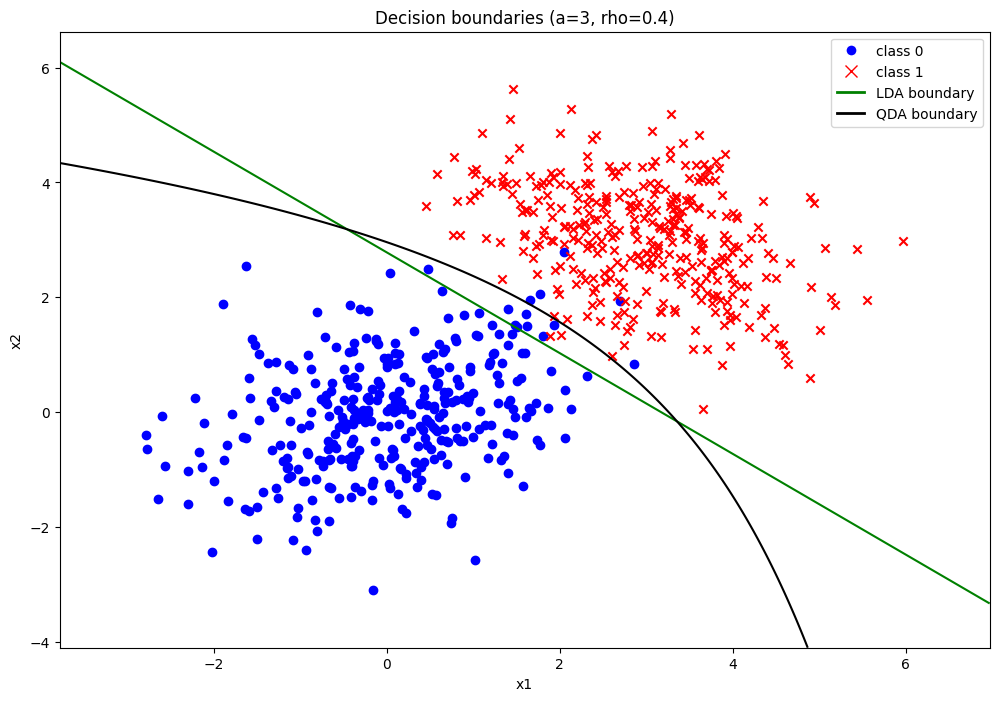

In [20]:
exp.experiment3(a=3, rho=0.4, pdf=pdf3)

In [21]:
pdf3.close()

#### **Comments on experiment 3**

The decision boundary determined by LDA is linear which is a result from the assumption of the same covariance matrix for both classes. On the other hand, QDA determines a nonlinear, quadratic decision boundary because it allows different covariance matrices for each class.<br>
You can see that the QDA boundary fits the actual data distribution better. The LDA boundary is simpler but in this case it still separates most of the observations well.

# **Theoretical Questions**

**Why might NB sometimes performs surprisingly well even when features are correlated?**

There might be a few reasons:
- in pratice, the correlations, dependencies are not so strong,
- even if the features are correlated their influence on classification might be similar in both classes so then in the expression p(x|1) / (p(x|1) + p(x|0)) errors might cancel out. 

**Accuracy may not be the best scoring rule for this model. If you had to evaluate
probabilities, which score would you use and why?**

Accuracy only evaluates class correctness but not the quality of probabilities. In order to evaluate the quality of probabilities I would choose cross-entropy score because it highly penalizes confident, wrong predictions.

**What happens to the covariance matrix estimator and the resulting decision boundary
in QDA when the number of observations in some class is close to (or smaller than)
p?**

When the number of observations in some class is close to or smaller than p then in QDA the covariance matrix is singular which means its determinant equals 0 and you cannot calculate the covariance matrix inverse. Then the estimator of the covariance matrix is unstable.


**How would look the model that combines the LDA and NB assumptions?**

LDA assumes the same covariance matrix for all observations regardless the class they belong to.<br>
NB assumes conditional independence of features so the covariance matrix is diagonal.<br>
The model that combines the LDA and NB assumptions would result in the same covariance matrix for all classes (LDA), but only with variances on the diagonal.

# **Experiment 4**
## **Real data**

#### **Dataset 1: Blood Transfusion Service Center Data Set**
https://www.openml.org/search?type=data&sort=runs&status=active&id=1464

In [22]:
import pandas as pd

In [23]:
pdf4 = PdfPages("BayesianReal.pdf")

In [24]:
data_blood = pd.read_csv("data/blood.csv")

In [25]:
data_blood.shape

(748, 5)

In [26]:
data_blood.head()

,V1,V2,V3,V4,Class
0,2,50,12500,98,2
1,0,13,3250,28,2
2,1,16,4000,35,2
3,2,20,5000,45,2
4,1,24,6000,77,1


In [27]:
X_blood = data_blood.drop(columns="Class")
y_blood = data_blood["Class"] - 1

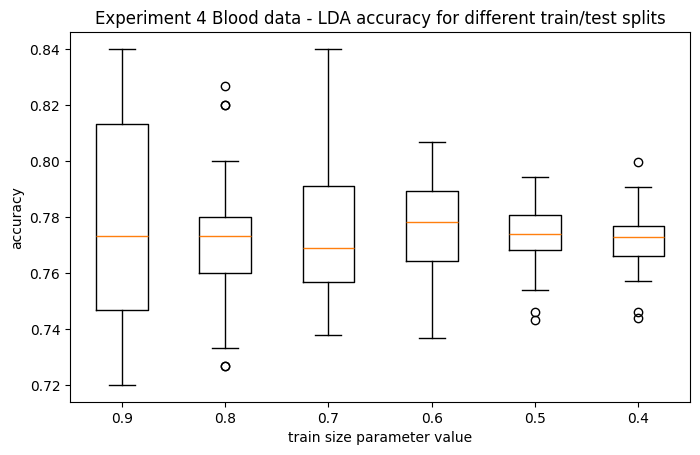

In [28]:
exp.experiment_real_data(method_name="LDA", X=X_blood, y=y_blood, data="Blood data", pdf=pdf4)

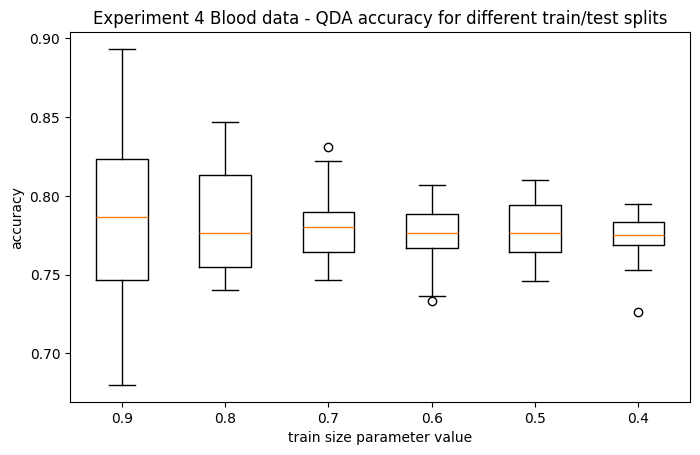

In [29]:
exp.experiment_real_data(method_name="QDA", X=X_blood, y=y_blood, data="Blood data", pdf=pdf4)

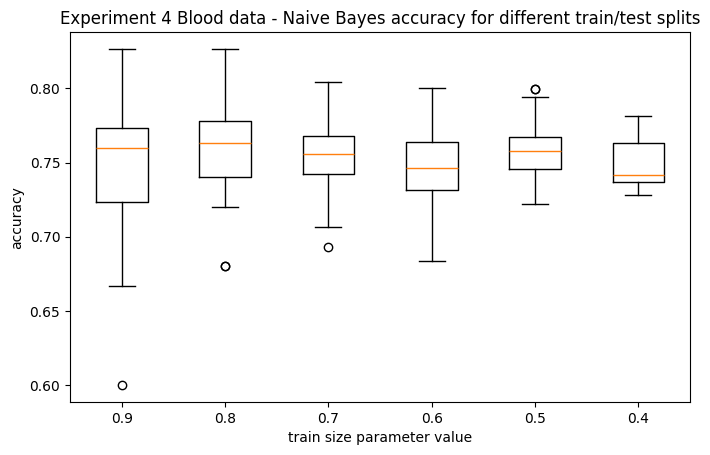

In [30]:
exp.experiment_real_data(method_name="Naive Bayes", X=X_blood, y=y_blood, data="Blood data", pdf=pdf4)

#### **Dataset 2: Pima Indians Diabetes Database**
https://www.openml.org/search?type=data&status=active&sort=runs&id=37

In [31]:
data_diabetes = pd.read_csv("data/diabetes.csv")

In [32]:
data_diabetes.shape

(768, 9)

In [33]:
data_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [34]:
X_diabetes = data_diabetes.drop(columns="Outcome")
y_diabetes = data_diabetes["Outcome"]

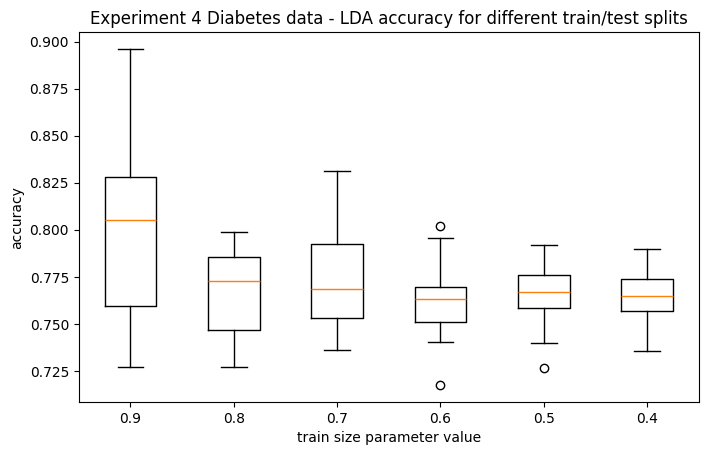

In [35]:
exp.experiment_real_data(method_name="LDA", X=X_diabetes, y=y_diabetes, data="Diabetes data", pdf=pdf4)

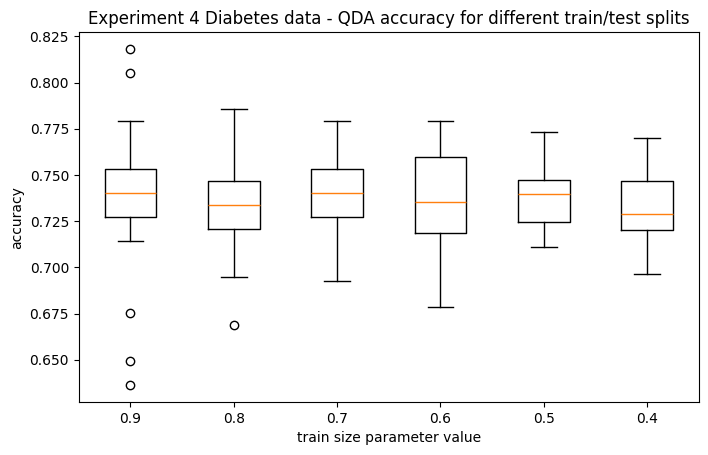

In [36]:
exp.experiment_real_data(method_name="QDA", X=X_diabetes, y=y_diabetes, data="Diabetes data", pdf=pdf4)

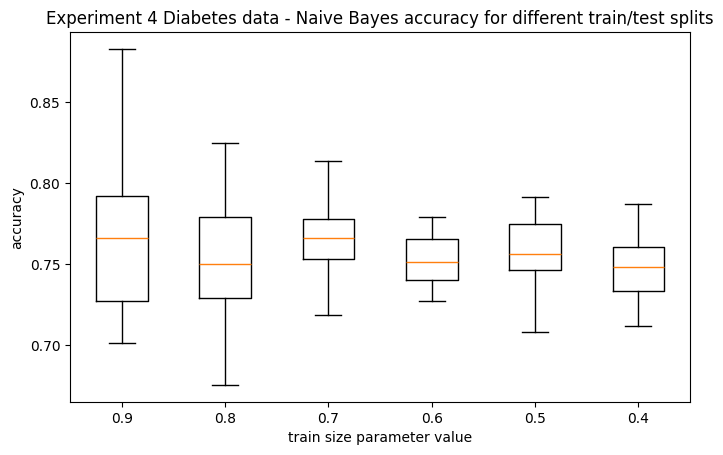

In [37]:
exp.experiment_real_data(method_name="Naive Bayes", X=X_diabetes, y=y_diabetes, data="Diabetes data", pdf=pdf4)

In [38]:
pdf4.close()

#### **Comments on comparison**

For the Blood dataset, all three methods achieve similar levels of accuracy across different train/test splits. The median accuracy is around 0.75–0.80 for most splits.<br>
For the Diabetes dataset, LDA and Naive Bayes achieve quite high results of accuracy, while QDA achieves slighlty lower.<br>
In some cases, you can aslo see that for train size = 0.9 the boxplots become noticeably wider. This occurs because the test set becomes very small which makes the estimated accuracy more sensitive to small changes in the test samples. As a result, different random splits may produce more variable accuracy values.

#### **Consider the numerical stability. Is it better to compute the likelihood? Or the log-likelihood?**

It is better to compute the log-likelihood in terms of numerical stability. Logarithm changes product for a sum which is way more numerically stable.